In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.datasets import make_classification
X,y = make_classification(n_features=5, n_informative=5, n_redundant=0, n_clusters_per_class=1)
print(X.shape, y.shape)

(100, 5) (100,)


In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.240582,0.790555,-0.277311,1.653137,-1.216387,1
1,-0.989823,1.981373,1.410963,1.965263,1.409712,0
2,1.689475,-1.501663,-1.312573,-0.328586,-1.394593,1
3,1.136198,0.552853,-0.079870,2.518551,0.104520,1
4,3.521495,-1.102190,-4.309391,0.067691,0.313864,1


# **Function for Row Sampling**

In [4]:
def sample_row(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

# **Function for feature Sampling**

In [5]:
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df


# **Function for combined Sampling**

In [6]:
def combined_sampling(df,row_percent,col_percent):
  new_df = sample_row(df,row_percent)
  return sample_features(new_df,col_percent)

In [7]:
df1 = sample_row(df,0.1)
df2 = sample_row(df,0.1)
df3 = sample_row(df,0.1)

In [8]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [9]:
clf1.fit(df1.iloc[:,:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,:5],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.5, 0.75, 'x[2] <= -0.353\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.625, 0.5, '  False')]

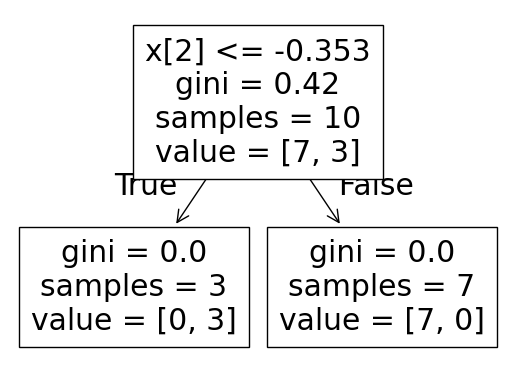

In [10]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.5, 0.75, 'x[0] <= -0.174\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.625, 0.5, '  False')]

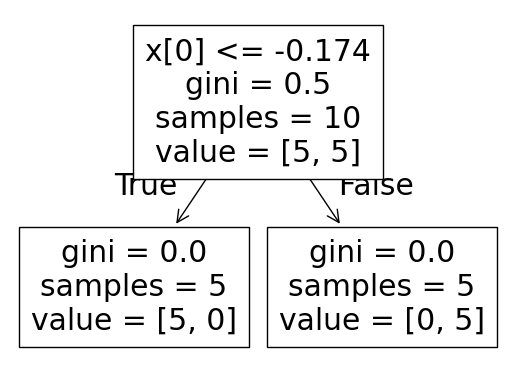

In [11]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[0] <= -0.174\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.625, 0.5, '  False')]

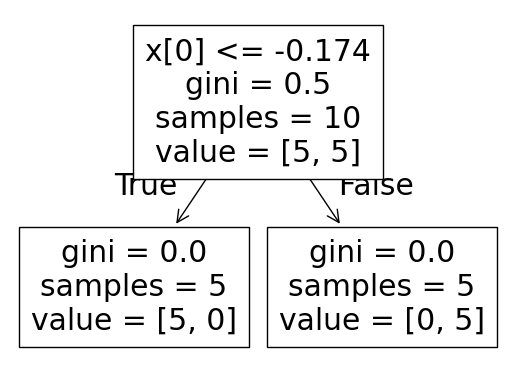

In [12]:
plot_tree(clf2)

In [17]:
clf1.predict(np.array([-0.989823,	1.981373	,1.410963,	1.965263,	1.409712]).reshape(1,5))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [16]:
clf2.predict(np.array([-0.989823,	1.981373	,1.410963,	1.965263,	1.409712]).reshape(1,5))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [18]:
clf3.predict(np.array([-0.989823,	1.981373	,1.410963,	1.965263,	1.409712]).reshape(1,5))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [19]:
df1 = sample_features(df,0.8)
df2 =sample_features(df,0.8)
df3 = sample_features(df,0.8)

/tmp/ipython-input-5-3778783950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipython-input-5-3778783950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipython-input-5-3778783950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

In [20]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col1', 'col3', 'col4', 'target'], dtype='object')
Index(['col3', 'col1', 'col5', 'col4', 'target'], dtype='object')
Index(['col5', 'col1', 'col3', 'col2', 'target'], dtype='object')


In [21]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [22]:
clf1.fit(df1.iloc[:,:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,:4],df3.iloc[:,-1])

DecisionTreeClassifier()

In [23]:
print(df1.head())
print(df2.head())
print(df3.head())

       col5      col1      col3      col4  target
0 -1.216387  0.240582 -0.277311  1.653137       1
1  1.409712 -0.989823  1.410963  1.965263       0
2 -1.394593  1.689475 -1.312573 -0.328586       1
3  0.104520  1.136198 -0.079870  2.518551       1
4  0.313864  3.521495 -4.309391  0.067691       1
       col3      col1      col5      col4  target
0 -0.277311  0.240582 -1.216387  1.653137       1
1  1.410963 -0.989823  1.409712  1.965263       0
2 -1.312573  1.689475 -1.394593 -0.328586       1
3 -0.079870  1.136198  0.104520  2.518551       1
4 -4.309391  3.521495  0.313864  0.067691       1
       col5      col1      col3      col2  target
0 -1.216387  0.240582 -0.277311  0.790555       1
1  1.409712 -0.989823  1.410963  1.981373       0
2 -1.394593  1.689475 -1.312573 -1.501663       1
3  0.104520  1.136198 -0.079870  0.552853       1
4  0.313864  3.521495 -4.309391 -1.102190       1


[Text(0.45454545454545453, 0.9, 'x[1] <= -0.289\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.18181818181818182, 0.7, 'x[0] <= -1.866\ngini = 0.097\nsamples = 39\nvalue = [37, 2]'),
 Text(0.3181818181818182, 0.8, 'True  '),
 Text(0.09090909090909091, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2727272727272727, 0.5, 'x[3] <= 1.986\ngini = 0.051\nsamples = 38\nvalue = [37, 1]'),
 Text(0.18181818181818182, 0.3, 'gini = 0.0\nsamples = 33\nvalue = [33, 0]'),
 Text(0.36363636363636365, 0.3, 'x[3] <= 2.031\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.2727272727272727, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.45454545454545453, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.7272727272727273, 0.7, 'x[2] <= 1.138\ngini = 0.335\nsamples = 61\nvalue = [13, 48]'),
 Text(0.5909090909090909, 0.8, '  False'),
 Text(0.6363636363636364, 0.5, 'gini = 0.0\nsamples = 47\nvalue = [0, 47]'),
 Text(0.8181818181818182, 0.5, 'x[2] <= 1.613\ngini = 0.133\

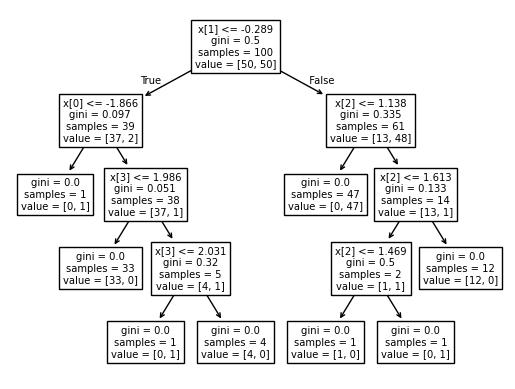

In [24]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.45454545454545453, 0.9, 'x[1] <= -0.289\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.18181818181818182, 0.7, 'x[2] <= -1.866\ngini = 0.097\nsamples = 39\nvalue = [37, 2]'),
 Text(0.3181818181818182, 0.8, 'True  '),
 Text(0.09090909090909091, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2727272727272727, 0.5, 'x[3] <= 1.986\ngini = 0.051\nsamples = 38\nvalue = [37, 1]'),
 Text(0.18181818181818182, 0.3, 'gini = 0.0\nsamples = 33\nvalue = [33, 0]'),
 Text(0.36363636363636365, 0.3, 'x[1] <= -0.546\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.2727272727272727, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.45454545454545453, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.7272727272727273, 0.7, 'x[0] <= 1.138\ngini = 0.335\nsamples = 61\nvalue = [13, 48]'),
 Text(0.5909090909090909, 0.8, '  False'),
 Text(0.6363636363636364, 0.5, 'gini = 0.0\nsamples = 47\nvalue = [0, 47]'),
 Text(0.8181818181818182, 0.5, 'x[0] <= 1.613\ngini = 0.133

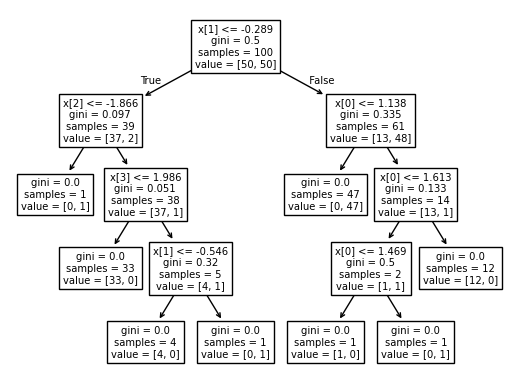

In [25]:
plot_tree(clf2)

[Text(0.4444444444444444, 0.9, 'x[1] <= -0.289\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.2222222222222222, 0.7, 'x[0] <= -1.866\ngini = 0.097\nsamples = 39\nvalue = [37, 2]'),
 Text(0.3333333333333333, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.5, 'x[0] <= -0.116\ngini = 0.051\nsamples = 38\nvalue = [37, 1]'),
 Text(0.2222222222222222, 0.3, 'x[0] <= -0.505\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.1111111111111111, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.3, 'gini = 0.0\nsamples = 33\nvalue = [33, 0]'),
 Text(0.6666666666666666, 0.7, 'x[2] <= 1.138\ngini = 0.335\nsamples = 61\nvalue = [13, 48]'),
 Text(0.5555555555555556, 0.8, '  False'),
 Text(0.5555555555555556, 0.5, 'gini = 0.0\nsamples = 47\nvalue = [0, 47]'),
 Text(0.7777777777777778, 0.5, 'x[3] <= -0.303\ngini = 0.133\nsa

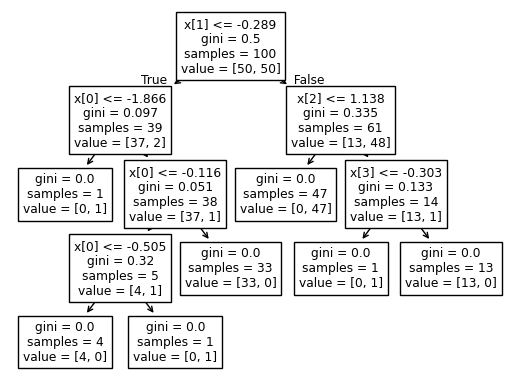

In [26]:
plot_tree(clf3)

In [27]:
clf1.predict(np.array([-1.216387,  0.240582, -0.277311,  0.790555	]).reshape(1,4))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [28]:
clf2.predict(np.array([-1.216387,  0.240582, -0.277311,  0.790555	]).reshape(1,4))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [29]:
clf3.predict(np.array([-1.216387,  0.240582, -0.277311,  0.790555	]).reshape(1,4))

array([1])

# **Now Combined sampling**

In [30]:
df1 = combined_sampling(df,0.5,0.5)
df2 =combined_sampling(df,0.5,0.5)
df3 = combined_sampling(df,0.5,0.5)

/tmp/ipython-input-5-3778783950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipython-input-5-3778783950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipython-input-5-3778783950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

In [31]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [32]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [33]:
print(df1.head())
print(df2.head())
print(df3.head())

        col3      col4  target
56  1.153513  0.681220       0
80 -1.207150  1.199631       1
42 -1.043644  1.383974       1
74  2.531092  1.402277       0
68 -0.195305  1.860630       1
        col3      col2  target
88  2.613914  1.613944       0
84 -0.126461 -0.179221       1
14  0.206546  2.091245       0
54 -2.097269  1.211383       1
2  -1.312573 -1.501663       1
        col5      col2  target
16 -0.113795 -0.916674       1
88  0.173546  1.613944       0
62 -1.190918 -2.161109       1
11  0.255245  0.619311       0
25 -1.983254 -1.637441       1


[Text(0.640625, 0.9166666666666666, 'x[0] <= 0.494\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.46875, 0.75, 'x[1] <= 1.891\ngini = 0.337\nsamples = 28\nvalue = [6, 22]'),
 Text(0.5546875, 0.8333333333333333, 'True  '),
 Text(0.3125, 0.5833333333333334, 'x[0] <= 0.11\ngini = 0.165\nsamples = 22\nvalue = [2, 20]'),
 Text(0.1875, 0.4166666666666667, 'x[0] <= -1.624\ngini = 0.1\nsamples = 19\nvalue = [1, 18]'),
 Text(0.125, 0.25, 'x[0] <= -1.951\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.0625, 0.08333333333333333, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.1875, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.4375, 0.4166666666666667, 'x[0] <= 0.309\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.375, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.625, 0.5833333333333334, 'x[0] <= -0.243\ngini =

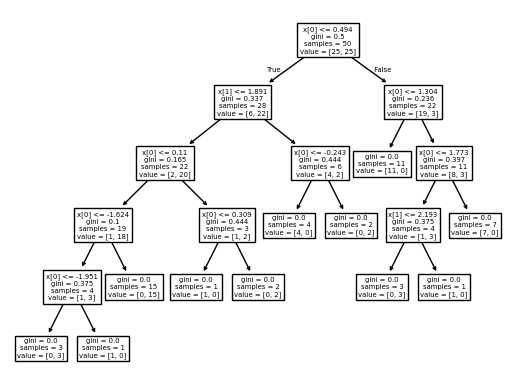

In [34]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.3333333333333333, 0.9, 'x[1] <= 0.215\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.16666666666666666, 0.7, 'gini = 0.0\nsamples = 23\nvalue = [0, 23]'),
 Text(0.25, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[0] <= -1.281\ngini = 0.198\nsamples = 27\nvalue = [24, 3]'),
 Text(0.41666666666666663, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6666666666666666, 0.5, 'x[1] <= 1.072\ngini = 0.077\nsamples = 25\nvalue = [24, 1]'),
 Text(0.5, 0.3, 'x[1] <= 0.904\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8333333333333334, 0.3, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]')]

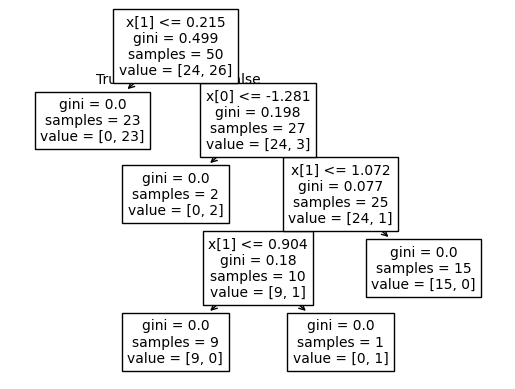

In [35]:
from sklearn.tree import plot_tree
plot_tree(clf2)

[Text(0.5555555555555556, 0.9, 'x[1] <= 0.146\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.3333333333333333, 0.7, 'x[0] <= 1.039\ngini = 0.185\nsamples = 29\nvalue = [3, 26]'),
 Text(0.4444444444444444, 0.8, 'True  '),
 Text(0.2222222222222222, 0.5, 'x[1] <= -0.297\ngini = 0.071\nsamples = 27\nvalue = [1, 26]'),
 Text(0.1111111111111111, 0.3, 'gini = 0.0\nsamples = 24\nvalue = [0, 24]'),
 Text(0.3333333333333333, 0.3, 'x[1] <= -0.183\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.2222222222222222, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4444444444444444, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4444444444444444, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.7777777777777778, 0.7, 'x[0] <= -0.157\ngini = 0.091\nsamples = 21\nvalue = [20, 1]'),
 Text(0.6666666666666667, 0.8, '  False'),
 Text(0.6666666666666666, 0.5, 'x[0] <= -0.505\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.5555555555555556, 0.3, 'gini = 0.0\nsamp

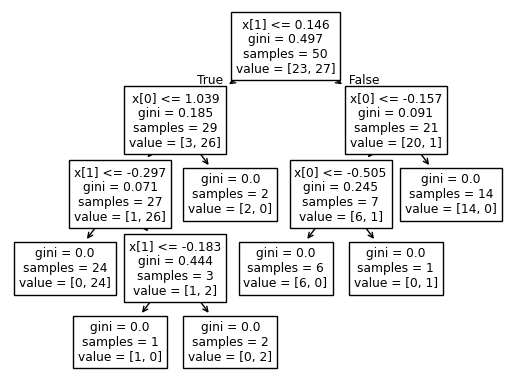

In [36]:
from sklearn.tree import plot_tree
plot_tree(clf3)

In [37]:
clf1.predict(np.array([1.153513 , 0.681220	]).reshape(1,2))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [38]:
clf2.predict(np.array([1.153513,  0.681220	]).reshape(1,2))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [39]:
clf3.predict(np.array([1.153513,  0.681220	]).reshape(1,2))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])